# Metric Data Analysis with Covariate Selection (2026-4-31)

This notebook is analysis-only (no forecasting model training).

## Section 1
1. Load data from `config_.yaml` in isolated cells
2. Plot target metric against time
3. Check stationarity (ADF only)
4. Plot ACF and PACF
5. Seasonal decomposition
6. Non-linearity check

## Section 2
7. Feature engineering and candidate set construction
8. Stationarity transform -> Correlation/MI -> VIF -> Granger

In [ ]:
%%capture
%pip install --upgrade pyyaml pandas numpy scipy matplotlib seaborn statsmodels scikit-learn pyarrow

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import yaml
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

sns.set_style('whitegrid')

## Utility Functions (Notebook-Local)

The analysis below is self-contained. All helper functions are defined in this notebook so you can review logic in one place and avoid external `script_` dependencies.

In [43]:
def load_config(config_path: str | Path = 'config_.yaml') -> Dict:
    """Load YAML configuration into a dictionary."""
    config_path = Path(config_path)
    with config_path.open('r', encoding='utf-8') as fh:
        return yaml.safe_load(fh)


def load_local_table(path_like: str | Path, date_col: str = 'DATE') -> pd.DataFrame:
    """Load a local CSV/parquet file and normalize date to month-end."""
    path = Path(path_like)
    if path.suffix.lower() == '.csv':
        df = pd.read_csv(path)
    elif path.suffix.lower() == '.parquet':
        df = pd.read_parquet(path)
    else:
        raise ValueError(f'Unsupported file extension: {path.suffix}')

    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col]).dt.to_period('M').dt.to_timestamp('M')
    return df


def build_metric_series(config: Dict, raw_df: pd.DataFrame, metric_name: str | None = None) -> pd.Series:
    """Build a single monthly target series using config filters."""
    c = config['columns']
    metric = metric_name or config.get('metric')

    mask = (
        (raw_df[c['portfolio']] == config['portfolio'])
        & (raw_df[c['sub_portfolio']] == config['sub_portfolio'])
        & (raw_df[c['forecast_type']] == config['forecast_type'])
        & (raw_df[c['metric']] == metric)
    )

    series = (
        raw_df.loc[mask, [c['date'], c['value']]]
        .groupby(c['date'], as_index=True)[c['value']]
        .sum()
        .sort_index()
        .astype(float)
    )
    series.index = pd.DatetimeIndex(series.index)
    series.name = str(metric)
    return series


def build_metric_columns(config: Dict, raw_df: pd.DataFrame, metric_names: Iterable[str]) -> pd.DataFrame:
    """Return DATE-indexed metric columns from raw data for selected metric names."""
    out = pd.DataFrame()
    for metric_name in list(metric_names):
        s = build_metric_series(config, raw_df, metric_name=metric_name)
        out[str(metric_name)] = s

    out.index = pd.DatetimeIndex(out.index)
    return out.sort_index()


def pivot_external_table(
    df: pd.DataFrame,
    date_col: str,
    value_col: str,
    category_col: str,
    portfolio_col: str,
    sub_portfolio_col: str,
    forecast_type_col: str,
    portfolio: str,
    sub_portfolio: str,
    forecast_type: str,
) -> pd.DataFrame:
    """Filter and pivot an external feature table into DATE-indexed wide format."""
    filt = (
        (df[portfolio_col] == portfolio)
        & (df[sub_portfolio_col] == sub_portfolio)
        & (df[forecast_type_col] == forecast_type)
    )
    sub = df.loc[filt, [date_col, category_col, value_col]].copy()

    wide = (
        sub.groupby([date_col, category_col], as_index=False)[value_col]
        .mean()
        .pivot(index=date_col, columns=category_col, values=value_col)
        .sort_index()
    )
    wide.columns = [str(col) for col in wide.columns]
    wide.index = pd.DatetimeIndex(wide.index)
    return wide


def adf_stationarity_check(series: pd.Series, alpha: float = 0.05) -> Dict[str, object]:
    """Run ADF test and return summary dictionary."""
    s = series.dropna().astype(float)
    stat, p_val, used_lag, n_obs, critical_values, _ = adfuller(s, autolag='AIC')
    return {
        'test': 'ADF',
        'statistic': float(stat),
        'p_value': float(p_val),
        'used_lag': int(used_lag),
        'n_obs': int(n_obs),
        'critical_5pct': float(critical_values['5%']),
        'is_stationary': bool(float(p_val) < alpha),
    }


def make_stationary(series: pd.Series, max_diffs: int = 2, alpha: float = 0.05) -> Dict[str, object]:
    """Apply differencing until ADF stationarity passes or max_diffs is reached."""
    s = series.copy()
    for diff_order in range(max_diffs + 1):
        check = adf_stationarity_check(s.dropna(), alpha=alpha)
        if bool(check['is_stationary']):
            return {'series': s, 'diff_order': int(diff_order), 'check': check}
        if diff_order < max_diffs:
            s = s.diff()

    return {
        'series': s,
        'diff_order': int(max_diffs),
        'check': adf_stationarity_check(s.dropna(), alpha=alpha),
    }


def stl_decompose(series: pd.Series, period: int = 12, robust: bool = True) -> Dict[str, pd.Series]:
    """Run STL and return observed/trend/seasonal/residual/smooth series."""
    s = series.dropna().astype(float).copy()
    s.index = pd.to_datetime(s.index).to_period('M').to_timestamp('M')
    s = s.sort_index()

    fit = STL(s, period=int(period), robust=bool(robust)).fit()
    trend = pd.Series(fit.trend, index=s.index, name='trend')
    seasonal = pd.Series(fit.seasonal, index=s.index, name='seasonal')
    residual = pd.Series(fit.resid, index=s.index, name='residual')
    smooth = pd.Series(trend.values + seasonal.values, index=s.index, name='smooth')

    return {
        'observed': s,
        'trend': trend,
        'seasonal': seasonal,
        'residual': residual,
        'smooth': smooth,
    }


def bds_nonlinearity_test(series: pd.Series, alpha: float = 0.05) -> Dict[str, object]:
    """Run BDS test with graceful fallback if unavailable."""
    s = series.dropna().astype(float)
    out: Dict[str, object] = {
        'test': 'BDS',
        'is_nonlinear': False,
        'p_value': np.nan,
        'statistic': np.nan,
        'message': '',
    }

    try:
        from statsmodels.tsa.stattools import bds

        stat, p_val = bds(s.values)
        p_val_f = float(np.ravel(p_val)[0])
        stat_f = float(np.ravel(stat)[0])
        out.update(
            {
                'is_nonlinear': bool(p_val_f < alpha),
                'p_value': p_val_f,
                'statistic': stat_f,
                'message': 'BDS test executed successfully.',
            }
        )
        return out
    except Exception as ex:
        out['message'] = f'BDS test unavailable or failed: {ex}'
        return out


def proxy_nonlinearity_test(series: pd.Series, alpha: float = 0.05, lags: int = 2) -> Dict[str, object]:
    """Proxy nonlinearity test using AR residual relationship."""
    s = series.dropna().astype(float).values
    out: Dict[str, object] = {
        'test': 'AR-residual-proxy',
        'is_nonlinear': False,
        'p_value': np.nan,
        'message': '',
    }

    try:
        from scipy import stats
        from statsmodels.tsa.ar_model import AutoReg

        fit = AutoReg(s, lags=lags).fit()
        resid = np.asarray(fit.resid, dtype=float)
        fitted_sq = np.asarray(fit.fittedvalues, dtype=float) ** 2

        min_len = int(min(len(resid), len(fitted_sq)))
        _, p_val = stats.pearsonr(resid[-min_len:], fitted_sq[-min_len:])
        out.update(
            {
                'is_nonlinear': bool(float(p_val) < alpha),
                'p_value': float(p_val),
                'message': 'Proxy nonlinearity test executed successfully.',
            }
        )
        return out
    except Exception as ex:
        out['message'] = f'Proxy nonlinearity test failed: {ex}'
        return out


def apply_stationarity_transforms(
    df: pd.DataFrame,
    target_col: str,
    drop_cols: Iterable[str],
    max_diffs: int = 2,
    alpha: float = 0.05,
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, int]]:
    """Difference each feature and target until ADF stationarity passes."""
    drop_set = set(drop_cols)
    feature_cols = [c for c in df.columns if c not in drop_set]

    transformed = df.copy()
    diff_orders: Dict[str, int] = {}

    for col in feature_cols:
        out = make_stationary(transformed[col], max_diffs=max_diffs, alpha=alpha)
        transformed[col] = out['series']
        diff_orders[col] = int(out['diff_order'])

    target_out = make_stationary(transformed[target_col], max_diffs=max_diffs, alpha=alpha)
    target_series = pd.Series(target_out['series'], name=target_col)

    merged = pd.concat([transformed[feature_cols], target_series], axis=1).dropna().reset_index(drop=True)
    x = merged[feature_cols].copy()
    y = merged[target_col].copy()
    return x, y, diff_orders


def screen_by_correlation_and_mi(
    x_df: pd.DataFrame,
    y_series: pd.Series,
    lags: Iterable[int] = (0, 1, 2, 3),
    corr_threshold: float = 0.25,
    mi_threshold: float = 0.05,
) -> Tuple[pd.DataFrame, List[str]]:
    """Keep features that pass correlation OR mutual information thresholds."""
    rows = []

    for col in x_df.columns:
        max_corr = 0.0
        max_mi = 0.0

        for lag in list(lags):
            lagged = x_df[col].shift(int(lag))
            pair = pd.concat([lagged, y_series], axis=1).dropna()
            if len(pair) < 10:
                continue

            pair.columns = ['feature', 'target']
            corr = float(abs(pair['feature'].corr(pair['target'])))
            if not np.isnan(corr):
                max_corr = max(max_corr, corr)

            mi = float(
                mutual_info_regression(
                    pair[['feature']].values,
                    pair['target'].values,
                    random_state=42,
                )[0]
            )
            max_mi = max(max_mi, mi)

        rows.append(
            {
                'feature': col,
                'max_corr': round(max_corr, 6),
                'max_mi': round(max_mi, 6),
                'pass_screen': bool((max_corr >= corr_threshold) or (max_mi >= mi_threshold)),
            }
        )

    score_df = pd.DataFrame(rows).sort_values(['max_corr', 'max_mi'], ascending=False).reset_index(drop=True)
    kept = score_df[score_df['pass_screen']]['feature'].tolist()
    return score_df, kept


def _compute_vif_table(feature_df: pd.DataFrame) -> pd.DataFrame:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_df.fillna(0.0))
    scaled_df = pd.DataFrame(scaled, columns=feature_df.columns)

    vif_vals = [variance_inflation_factor(scaled_df.values, i) for i in range(scaled_df.shape[1])]
    return pd.DataFrame({'feature': scaled_df.columns, 'vif': vif_vals}).sort_values('vif', ascending=False)


def reduce_multicollinearity_vif(
    x_df: pd.DataFrame,
    candidate_features: List[str],
    mi_score_df: pd.DataFrame,
    vif_threshold: float = 5.0,
) -> Tuple[List[str], pd.DataFrame]:
    """Iteratively remove high-VIF features while preferring higher-MI columns."""
    kept = list(candidate_features)
    mi_map = dict(mi_score_df[['feature', 'max_mi']].values) if len(mi_score_df) else {}

    while len(kept) > 2:
        vif_df = _compute_vif_table(x_df[kept])
        max_vif = float(vif_df.iloc[0]['vif'])
        if max_vif <= vif_threshold:
            return kept, vif_df.reset_index(drop=True)

        high_vif = vif_df[vif_df['vif'] > vif_threshold]['feature'].tolist()
        to_drop = min(high_vif, key=lambda f: float(mi_map.get(f, 0.0)))
        kept.remove(to_drop)

    final_vif = _compute_vif_table(x_df[kept]) if len(kept) else pd.DataFrame(columns=['feature', 'vif'])
    return kept, final_vif.reset_index(drop=True)


def granger_causality_filter(
    x_df: pd.DataFrame,
    y_series: pd.Series,
    candidate_features: List[str],
    max_lag: int = 3,
    p_threshold: float = 0.10,
) -> Tuple[pd.DataFrame, List[str]]:
    """Select features whose best Granger lag p-value passes threshold."""
    rows = []
    kept: List[str] = []

    for feature in candidate_features:
        try:
            pair = pd.concat([y_series, x_df[feature]], axis=1).dropna()
            pair.columns = ['target', 'feature']
            if len(pair) < 15:
                continue

            test_result = grangercausalitytests(pair[['target', 'feature']], maxlag=max_lag, verbose=False)
            lag_pvals = {lag: float(test_result[lag][0]['ssr_ftest'][1]) for lag in range(1, max_lag + 1)}
            best_lag = int(min(lag_pvals, key=lag_pvals.get))
            best_p = float(lag_pvals[best_lag])
            is_causal = bool(best_p < p_threshold)

            rows.append(
                {
                    'feature': feature,
                    'best_lag': best_lag,
                    'best_p': round(best_p, 6),
                    'is_selected': is_causal,
                }
            )
            if is_causal:
                kept.append(feature)
        except Exception:
            continue

    result_df = pd.DataFrame(rows).sort_values('best_p', ascending=True).reset_index(drop=True)
    return result_df, kept

## Load Config
This cell loads the analysis configuration from `config_.yaml` using a local `load_config` function. The configuration file contains key parameters for portfolio filters, target metric, date range, and feature source definitions.

In [44]:
config = load_config('config_.yaml')

candidate_metrics_raw = config.get('analysis', {}).get('candidate_metrics')
candidate_metrics = list(candidate_metrics_raw or [])

print('Portfolio      :', config['portfolio'])
print('Sub-Portfolio  :', config['sub_portfolio'])
print('Target Metric  :', config['metric'])
print('Forecast Type  :', config['forecast_type'])
print('Train Window   :', config['first_input_date'], '->', config['last_input_date'])
print('Feature Sources:', list(config.get('feature_sources', {}).keys()))
print('Candidate Metrics:', candidate_metrics if candidate_metrics else 'None configured')

Portfolio      : Buckeye
Sub-Portfolio  : LP
Target Metric  : Gross Credit Losses
Forecast Type  : Actual
Train Window   : 2019-12-31 -> 2022-12-31
Feature Sources: ['accounts', 'dq_roll_rates', 'metric_rates']
Candidate Metrics: None configured


### What `analysis.candidate_metrics` Means

`candidate_metrics` is an optional list of additional metrics from the raw metric table to use as candidate predictors.

How they are processed in this notebook:
1. For each metric name in `candidate_metrics`, a monthly series is built with the same portfolio/sub-portfolio/forecast filters.
2. These series are added as feature columns with `metric_` prefix.
3. They enter the same feature-selection flow as all other candidates (stationarity transform -> correlation/MI -> VIF -> Granger).

If the list is empty, no extra metric-based feature columns are added.

## Isolated Data Loading Cells
Each of the following cells loads a specific data table as defined in the config file. Data is loaded in isolation to ensure clarity and reproducibility. The loaded dataframes are displayed for inspection, allowing you to verify shapes and sample rows before further analysis.

In [45]:
date_col = config['columns']['date']

raw_df = load_local_table(config['paths']['raw_data'], date_col=date_col)
print('raw_df shape:', raw_df.shape)
display(raw_df.head())

raw_df shape: (106, 6)


,FORECAST_TYPE,PORTFOLIO,SUB_PORTFOLIO,METRIC,DATE,METRIC_VALUE
0,Actual,Buckeye,LP,Gross Credit Losses,2019-12-31,3759133.46
1,Actual,Buckeye,LP,Active Accounts,2019-12-31,99958.31
2,Actual,Buckeye,LP,Gross Credit Losses,2020-01-31,3437823.91
3,Actual,Buckeye,LP,Active Accounts,2020-01-31,103219.24
4,Actual,Buckeye,LP,Gross Credit Losses,2020-02-29,3575387.21


In [46]:
accounts_df = load_local_table(config['paths']['accounts'], date_col=date_col)
print('accounts_df shape:', accounts_df.shape)
display(accounts_df.head())

accounts_df shape: (204, 6)


,FORECAST_TYPE,PORTFOLIO,SUB_PORTFOLIO,ACCOUNT_TYPE,DATE,NO_OF_ACCOUNTS
0,Actual,Buckeye,LP,Active Accounts,2019-12-31,99958.310000
1,Actual,Buckeye,LP,Chargeoff Accounts,2019-12-31,493.512157
2,Actual,Buckeye,LP,Inactive Accounts,2019-12-31,82439.280369
3,Actual,Buckeye,LP,Total Accounts,2019-12-31,182397.590369
4,Actual,Buckeye,LP,Active Accounts,2020-01-31,103219.240000


In [47]:
dq_df = load_local_table(config['paths']['dq_roll_rates'], date_col=date_col)
print('dq_df shape:', dq_df.shape)
display(dq_df.head())

dq_df shape: (306, 6)


,FORECAST_TYPE,PORTFOLIO,SUB_PORTFOLIO,RATE_TYPE,DATE,RATE
0,Actual,Buckeye,LP,30+ DQ Rate,2019-12-31,0.041287
1,Actual,Buckeye,LP,30+ DQ Rate,2020-01-31,0.049475
2,Actual,Buckeye,LP,30+ DQ Rate,2020-02-29,0.050525
3,Actual,Buckeye,LP,30+ DQ Rate,2020-03-31,0.053589
4,Actual,Buckeye,LP,30+ DQ Rate,2020-04-30,0.050492


In [48]:
metric_rates_df = load_local_table(config['paths']['metric_rates'], date_col=date_col)
print('metric_rates_df shape:', metric_rates_df.shape)
display(metric_rates_df.head())

metric_rates_df shape: (102, 6)


,FORECAST_TYPE,PORTFOLIO,SUB_PORTFOLIO,METRIC,DATE,METRIC_VALUE
0,Actual,Buckeye,LP,Financial Charges Rate,2019-12-31,0.061014
1,Actual,Buckeye,LP,Expected Loss,2019-12-31,0.024445
2,Actual,Buckeye,LP,Financial Charges Rate,2020-01-31,0.068407
3,Actual,Buckeye,LP,Expected Loss,2020-01-31,0.021649
4,Actual,Buckeye,LP,Financial Charges Rate,2020-02-29,0.072428


In [49]:
target_series = build_metric_series(config, raw_df, metric_name=config['metric']).sort_index()

train_start = pd.Timestamp(config['first_input_date'])
train_end = pd.Timestamp(config['last_input_date'])
train_series = target_series[(target_series.index >= train_start) & (target_series.index <= train_end)].astype(float)

print('Target train rows:', len(train_series))
print('Target train range:', train_series.index.min(), '->', train_series.index.max())
display(train_series.head())

Target train rows: 37
Target train range: 2019-12-31 00:00:00 -> 2022-12-31 00:00:00


DATE
2019-12-31    3759133.46
2020-01-31    3437823.91
2020-02-29    3575387.21
2020-03-31    3739548.28
2020-04-30    3745378.96
Name: Gross Credit Losses, dtype: float64

## Section 1: Time Series Analysis
This section performs exploratory analysis on the target metric time series:
- Plot the metric over time
- Check stationarity using only the ADF test
- Plot ACF and PACF to assess autocorrelation
- Decompose the series into trend, seasonality, and residuals
- Test for non-linearity using BDS or proxy tests

Interpretation tip for stationarity: lower ADF p-value means stronger evidence against a unit root. In this notebook, a series is treated as stationary when `ADF p-value < alpha`.

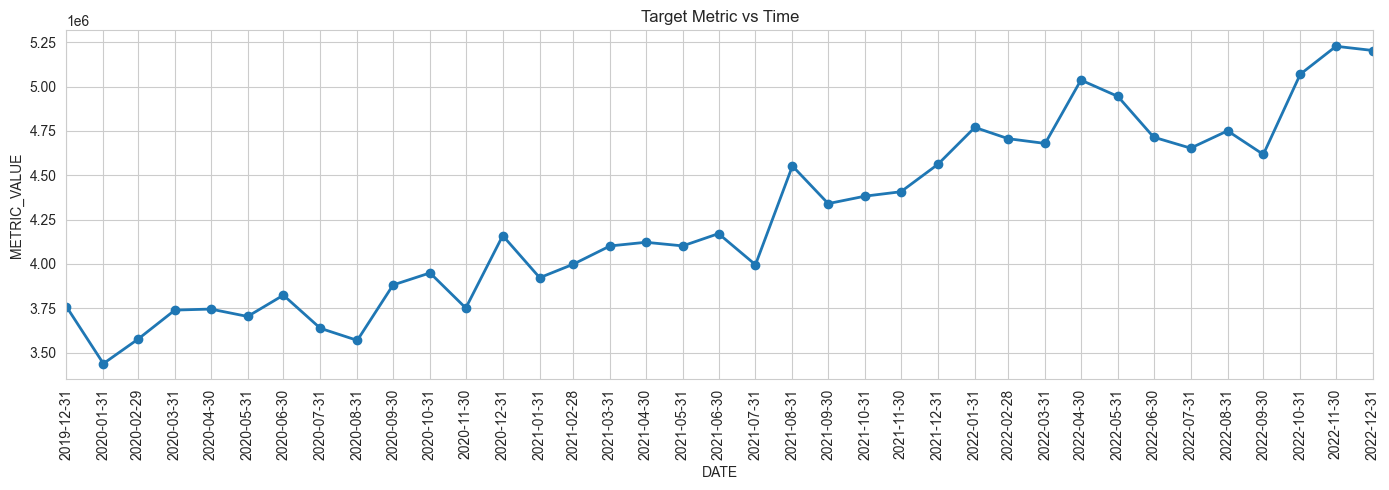

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_series.index, train_series.values, marker='o', linewidth=2)
ax.set_title('Target Metric vs Time')
ax.set_xlabel('DATE')
ax.set_ylabel('METRIC_VALUE')
ax.set_xticks(train_series.index)
ax.tick_params(axis='x', rotation=90)
ax.margins(x=0)
plt.tight_layout()
plt.show()

In [51]:
alpha = float(config['analysis']['stationarity_alpha'])

adf_out = adf_stationarity_check(train_series, alpha=alpha)
stationary_build = make_stationary(train_series, max_diffs=2, alpha=alpha)

display(pd.DataFrame([
    {
        'series': config['metric'],
        'adf_p_value': adf_out['p_value'],
        'adf_statistic': adf_out['statistic'],
        'is_stationary_adf': adf_out['is_stationary'],
        'diff_order_applied_for_stationary_version': stationary_build['diff_order'],
    }
]))

,series,adf_p_value,adf_statistic,is_stationary_adf,diff_order_applied_for_stationary_version
0,Gross Credit Losses,0.967076,0.115083,False,1


### How to Read the Stationarity Output

- `is_stationary_adf = True` means the original series already passes the ADF stationarity check.
- If `False`, use the differenced series from `stationary_build['series']` for lag diagnostics and downstream feature filtering.
- `diff_order_applied_for_stationary_version` shows how many differences were needed (0, 1, or 2).

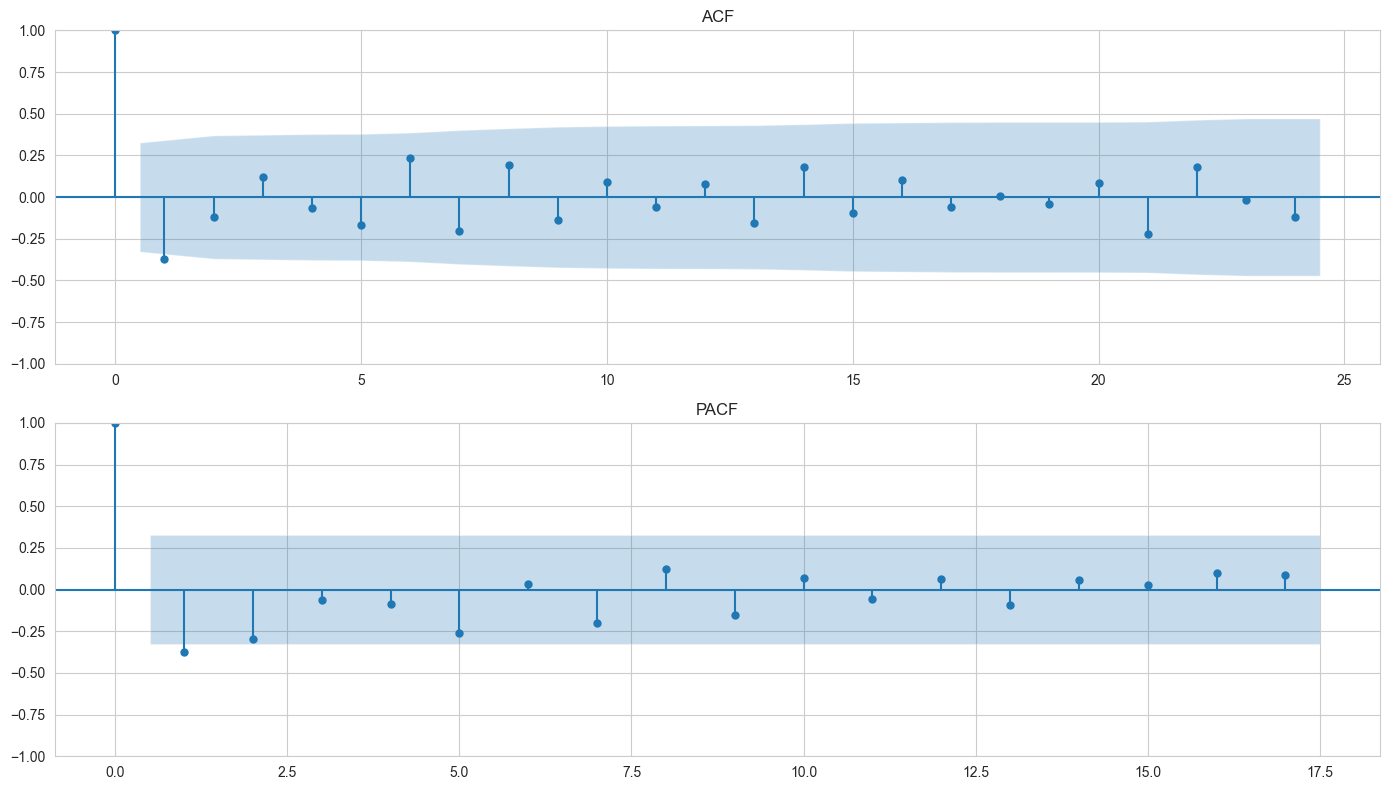

In [52]:
acf_lags = int(config['analysis']['acf_lags'])
pacf_lags = int(config['analysis']['pacf_lags'])
plot_series = stationary_build['series'].dropna().astype(float)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(plot_series, lags=min(acf_lags, len(plot_series) - 1), ax=axes[0])
axes[0].set_title('ACF')
plot_pacf(plot_series, lags=min(pacf_lags, max(1, len(plot_series) // 2 - 1)), method='ywm', ax=axes[1])
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

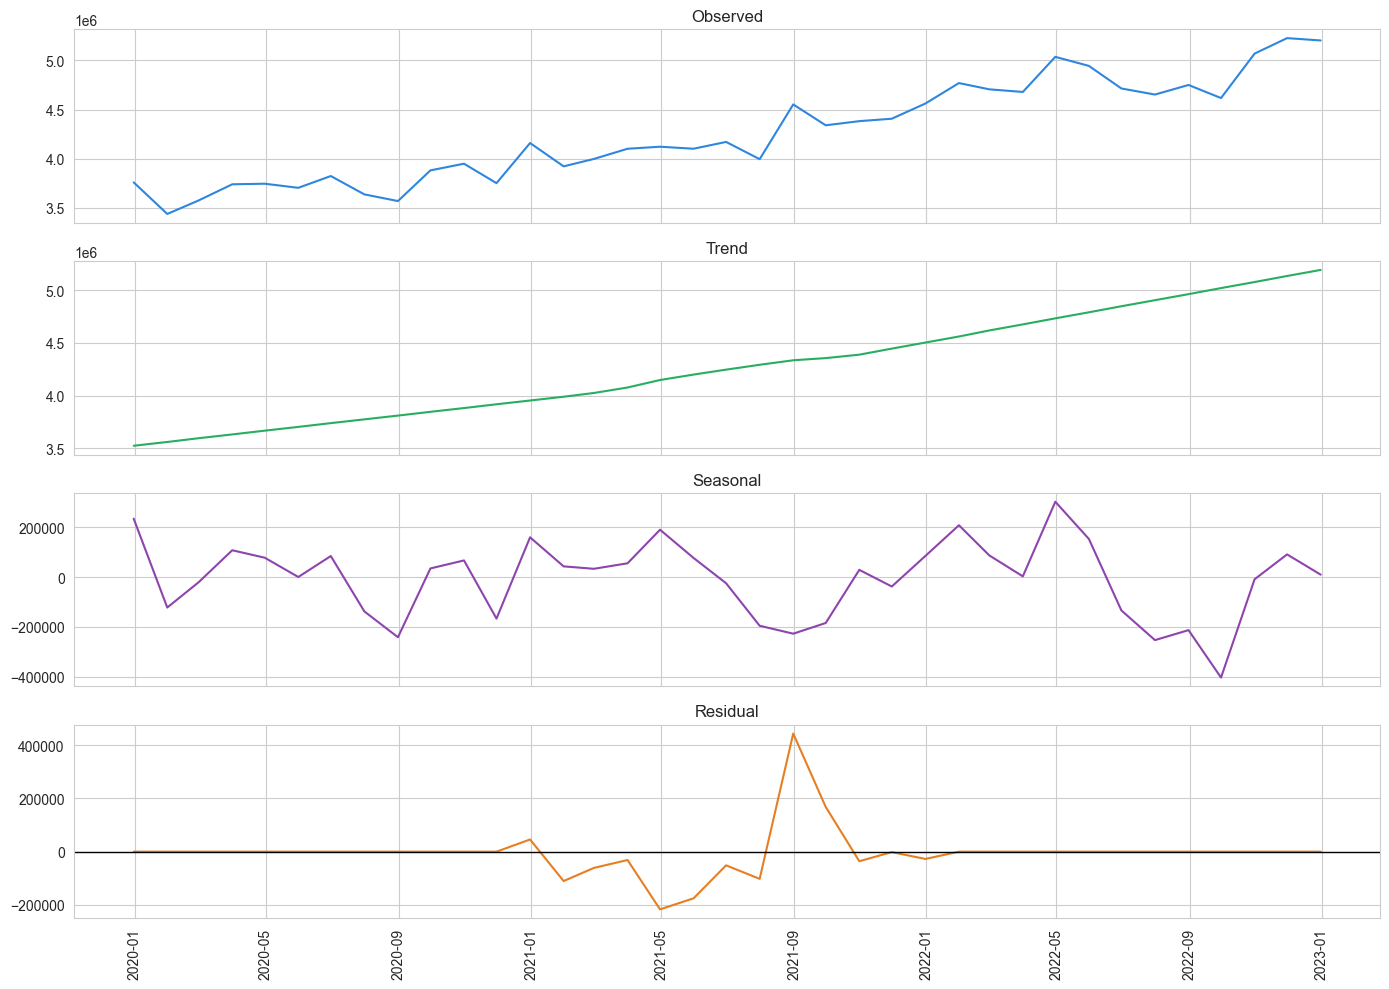

In [53]:
stl_period = int(config['analysis']['stl_period'])
decomp = stl_decompose(train_series, period=stl_period, robust=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomp['observed'].index, decomp['observed'].values, color='#2E86DE')
axes[0].set_title('Observed')
axes[1].plot(decomp['trend'].index, decomp['trend'].values, color='#27AE60')
axes[1].set_title('Trend')
axes[2].plot(decomp['seasonal'].index, decomp['seasonal'].values, color='#8E44AD')
axes[2].set_title('Seasonal')
axes[3].plot(decomp['residual'].index, decomp['residual'].values, color='#E67E22')
axes[3].axhline(0.0, color='black', linewidth=1)
axes[3].set_title('Residual')
axes[3].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

In [54]:
bds_result = bds_nonlinearity_test(train_series, alpha=alpha)
if str(bds_result.get('message', '')).startswith('BDS test unavailable'):
    proxy_result = proxy_nonlinearity_test(train_series, alpha=alpha, lags=2)
    nonlin_df = pd.DataFrame([proxy_result])
else:
    nonlin_df = pd.DataFrame([bds_result])

display(nonlin_df)

,test,is_nonlinear,p_value,statistic,message
0,BDS,True,1.188068e-183,28.90017,BDS test executed successfully.


## Section 2: Feature Selection
This section implements a stepwise feature selection pipeline:
1. Build candidate features from external sources and optional `analysis.candidate_metrics`
2. Apply stationarity transforms to all features and the target (ADF-based)
3. Screen features by correlation and mutual information (MI) with the target
4. Reduce multicollinearity using Variance Inflation Factor (VIF)
5. Filter features by Granger causality with the target

Each step is performed in a dedicated cell, with intermediate outputs shown for interpretation.

In [55]:
c = config['columns']
feature_tables = []
external_sources = config.get('feature_sources', {})
source_map = {
    'accounts': accounts_df,
    'dq_roll_rates': dq_df,
    'metric_rates': metric_rates_df,
}

for src_name, src_cfg in external_sources.items():
    src_df = source_map.get(src_name)
    if src_df is None or src_df.empty:
        continue

    wide = pivot_external_table(
        df=src_df,
        date_col=c['date'],
        value_col=src_cfg['value_col'],
        category_col=src_cfg['category_col'],
        portfolio_col=c['portfolio'],
        sub_portfolio_col=c['sub_portfolio'],
        forecast_type_col=c['forecast_type'],
        portfolio=config['portfolio'],
        sub_portfolio=config['sub_portfolio'],
        forecast_type=config['forecast_type'],
    )
    wide = wide.add_prefix(f"{src_cfg['prefix']}_")
    feature_tables.append(wide)

candidate_metrics = list((config.get('analysis', {}).get('candidate_metrics') or []))
metric_feature_df = build_metric_columns(config, raw_df, metric_names=candidate_metrics)
metric_feature_df.columns = [f"metric_{col}" for col in metric_feature_df.columns]

feature_df = train_series.rename('METRIC_VALUE').to_frame()
feature_df = feature_df.join(metric_feature_df, how='left')
for tbl in feature_tables:
    feature_df = feature_df.join(tbl, how='left')

feature_df = feature_df.sort_index()
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
display(feature_df.head())
print('Feature frame shape:', feature_df.shape)

,METRIC_VALUE,acct_Active Accounts,acct_Chargeoff Accounts,acct_Inactive Accounts,acct_Total Accounts,dq_0 to 1 Roll Rate,dq_2 to 3 Roll Rate,dq_30+ DQ Rate,dq_DQ Bucket 1 Rate,dq_DQ Bucket 3 Rate,dq_Prob DQ 1 to CO,mr_Expected Loss,mr_Financial Charges Rate
DATE,,,,,,,,,,,,,
2019-12-31,3759133.46,99958.31,493.512157,82439.280369,182397.590369,0.027027,0.015925,0.041287,0.032398,0.016166,0.011324,0.024445,0.061014
2020-01-31,3437823.91,103219.24,448.653067,83546.909935,186766.149935,0.032392,0.022927,0.049475,0.040340,0.019152,0.012464,0.021649,0.068407
2020-02-29,3575387.21,98277.78,505.503648,80348.026188,178625.806188,0.039330,0.024663,0.050525,0.042709,0.020498,0.015153,0.023647,0.072428
2020-03-31,3739548.28,97260.83,509.177396,79401.101109,176661.931109,0.037261,0.025172,0.053589,0.046118,0.021799,0.015817,0.024992,0.072333
2020-04-30,3745378.96,98626.39,385.610089,80394.481414,179020.871414,0.037760,0.024611,0.050492,0.043780,0.019000,0.015790,0.024684,0.074036


Feature frame shape: (37, 13)


In [56]:
fs_cfg = config['analysis']['feature_selection']

fs_df = feature_df.reset_index().rename(columns={'index': 'DATE'})
x_stationary, y_stationary, diff_orders = apply_stationarity_transforms(
    df=fs_df,
    target_col='METRIC_VALUE',
    drop_cols=['DATE', 'METRIC_VALUE'],
    max_diffs=int(fs_cfg.get('max_diffs', 2)),
    alpha=float(config['analysis']['stationarity_alpha']),
)

print('Stationary feature matrix shape:', x_stationary.shape)
print('Stationary target length:', len(y_stationary))
display(pd.DataFrame({'feature': list(diff_orders.keys()), 'diff_order': list(diff_orders.values())}).head(20))

Stationary feature matrix shape: (36, 12)
Stationary target length: 36


,feature,diff_order
0,acct_Active Accounts,1
1,acct_Chargeoff Accounts,0
2,acct_Inactive Accounts,1
3,acct_Total Accounts,1
4,dq_0 to 1 Roll Rate,0
5,dq_2 to 3 Roll Rate,0
6,dq_30+ DQ Rate,0
7,dq_DQ Bucket 1 Rate,0
8,dq_DQ Bucket 3 Rate,0
9,dq_Prob DQ 1 to CO,0


In [57]:
score_df, step2_features = screen_by_correlation_and_mi(
    x_df=x_stationary,
    y_series=y_stationary,
    lags=list(fs_cfg.get('lags', [0, 1, 2, 3])),
    corr_threshold=float(fs_cfg.get('corr_threshold', 0.25)),
    mi_threshold=float(fs_cfg.get('mi_threshold', 0.05)),
)

print('Features before screen:', x_stationary.shape[1])
print('Features after screen :', len(step2_features))
display(score_df.head(25))

Features before screen: 12
Features after screen : 8


,feature,max_corr,max_mi,pass_screen
0,mr_Expected Loss,0.841109,0.537664,True
1,acct_Chargeoff Accounts,0.243858,0.057790,True
2,mr_Financial Charges Rate,0.226948,0.025306,False
3,dq_30+ DQ Rate,0.224975,0.088279,True
4,dq_Prob DQ 1 to CO,0.224944,0.094578,True
5,dq_DQ Bucket 3 Rate,0.221322,0.000000,False
6,acct_Active Accounts,0.217428,0.003454,False
7,acct_Total Accounts,0.213971,0.079525,True
8,dq_2 to 3 Roll Rate,0.212984,0.000000,False
9,dq_0 to 1 Roll Rate,0.206620,0.071312,True


In [58]:
step3_features, vif_df = reduce_multicollinearity_vif(
    x_df=x_stationary,
    candidate_features=step2_features,
    mi_score_df=score_df,
    vif_threshold=float(fs_cfg.get('vif_threshold', 5.0)),
)

print('Features after VIF check:', len(step3_features))
display(vif_df.head(25))

Features after VIF check: 4


,feature,vif
0,acct_Total Accounts,2.089017
1,mr_Expected Loss,1.538476
2,dq_Prob DQ 1 to CO,1.393197
3,acct_Chargeoff Accounts,1.054462


In [59]:
causality_df, final_features = granger_causality_filter(
    x_df=x_stationary,
    y_series=y_stationary,
    candidate_features=step3_features,
    max_lag=int(fs_cfg.get('granger_max_lag', 3)),
    p_threshold=float(fs_cfg.get('granger_p_threshold', 0.10)),
)

print('Features after Granger filter:', len(final_features))
display(causality_df.head(25))

Features after Granger filter: 2


c:\Users\praneethf\Desktop\forecasting\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\praneethf\Desktop\forecasting\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\praneethf\Desktop\forecasting\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\praneethf\Desktop\forecasting\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,feature,best_lag,best_p,is_selected
0,mr_Expected Loss,3,0.018606,True
1,acct_Total Accounts,3,0.051753,True
2,dq_Prob DQ 1 to CO,3,0.110494,False
3,acct_Chargeoff Accounts,3,0.359392,False


In [60]:
summary_df = pd.DataFrame([
    {
        'step_1_stationary_features': int(x_stationary.shape[1]),
        'step_2_corr_mi_features': int(len(step2_features)),
        'step_3_vif_features': int(len(step3_features)),
        'step_4_granger_features': int(len(final_features)),
    }
])
display(summary_df)

print('Final selected features:')
for i, feat in enumerate(final_features, start=1):
    print(f'{i:2d}. {feat}')

,step_1_stationary_features,step_2_corr_mi_features,step_3_vif_features,step_4_granger_features
0,12,8,4,2


Final selected features:
 1. mr_Expected Loss
 2. acct_Total Accounts
